# Manual TSP portfolio analysis

Adjust `MANUAL_WEIGHTS` to create a custom TSP portfolio. The notebook downloads and caches official TSP fund prices, compares the portfolio with the configurable benchmark ticker (SPY by default), and reports CAGR, Sharpe, MaxDD, Sortino, and Calmar with a historical growth plot.

In [6]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import yfinance as yf
from IPython.display import display

warnings.filterwarnings('ignore', category=RuntimeWarning)
plt.style.use('seaborn-v0_8-whitegrid')

## Portfolio configuration

Weights are target allocations. With `PORTFOLIO_METHOD = 'daily_rebalanced'`, those allocations are restored each trading day. With `'buy_and_hold'`, weights drift with fund performance after the initial allocation.

In [7]:
DATA_URL = 'https://www.tsp.gov/data/fund-price-history.csv'
DATA_DIR = Path('data')
CACHE_PATH = DATA_DIR / 'fund-price-history.csv'
RISK_FREE_RATE = 0.02
TRADING_DAYS = 252
START_DATE = None  # e.g. '2010-01-01'; None uses the common history
PORTFOLIO_METHOD = 'daily_rebalanced'  # 'daily_rebalanced' or 'buy_and_hold'
BENCHMARK_TICKER = 'SPY'
BENCHMARK_CACHE_PATH = DATA_DIR / f'{BENCHMARK_TICKER.lower()}-adjusted-close.csv'

MANUAL_WEIGHTS = {
    'G Fund': 0.34,
    'F Fund': 0.00,
    'C Fund': 0.66,
    'S Fund': 0.00,
    'I Fund': 0.00,
}

## Benchmark against SPY

In [8]:
benchmark_start = portfolio_value.index.min().strftime('%Y-%m-%d')
benchmark_end = (portfolio_value.index.max() + pd.Timedelta(days=1)).strftime('%Y-%m-%d')

if BENCHMARK_CACHE_PATH.exists():
    benchmark_frame = pd.read_csv(BENCHMARK_CACHE_PATH, index_col=0, parse_dates=True)
    benchmark_prices = benchmark_frame.iloc[:, 0].rename(BENCHMARK_TICKER)
    print(f'Using cached {BENCHMARK_TICKER} data: {BENCHMARK_CACHE_PATH}')
else:
    benchmark_download = yf.download(
        BENCHMARK_TICKER,
        start=benchmark_start,
        end=benchmark_end,
        auto_adjust=True,
        progress=False,
        threads=False,
    )
    if benchmark_download.empty:
        raise RuntimeError(f'No benchmark data returned for {BENCHMARK_TICKER}.')
    benchmark_prices = benchmark_download['Close']
    if isinstance(benchmark_prices, pd.DataFrame):
        benchmark_prices = (
            benchmark_prices[BENCHMARK_TICKER]
            if BENCHMARK_TICKER in benchmark_prices.columns
            else benchmark_prices.iloc[:, 0]
        )
    benchmark_prices = benchmark_prices.rename(BENCHMARK_TICKER).dropna()
    benchmark_prices.to_frame().to_csv(BENCHMARK_CACHE_PATH)
    print(f'Downloaded {BENCHMARK_TICKER} data to {BENCHMARK_CACHE_PATH}')

benchmark_prices.index = pd.to_datetime(benchmark_prices.index)
if benchmark_prices.index.tz is not None:
    benchmark_prices.index = benchmark_prices.index.tz_localize(None)
benchmark_returns = benchmark_prices.pct_change().dropna()
comparison_returns = pd.concat(
    [portfolio_returns.rename('Manual TSP Portfolio'), benchmark_returns],
    axis=1,
).dropna()
if comparison_returns.empty:
    raise ValueError('The portfolio and benchmark have no overlapping dates.')
comparison_value = 100 * (1 + comparison_returns).cumprod()
comparison_metrics = pd.DataFrame({
    column: performance_metrics(comparison_value[column])
    for column in comparison_value.columns
}).T
print(f'Comparison range: {comparison_value.index.min().date()} to {comparison_value.index.max().date()}')
display(comparison_metrics.style.format({
    'CAGR': '{:.2%}', 'Sharpe': '{:.2f}', 'MaxDD': '{:.2%}',
    'Sortino': '{:.2f}', 'Calmar': '{:.2f}', 'Years': '{:.1f}',
}))

Using cached SPY data: data/spy-adjusted-close.csv
Comparison range: 2011-02-01 to 2026-08-21


,CAGR,Sharpe,MaxDD,Sortino,Calmar,Years
Manual TSP Portfolio,10.44%,0.77,-23.27%,1.07,0.45,15.6
SPY,13.41%,0.71,-33.72%,1.00,0.40,15.6


## Download and clean TSP prices

In [9]:
DATA_DIR.mkdir(exist_ok=True)

if not CACHE_PATH.exists():
    headers = {
        'User-Agent': (
            'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) '
            'AppleWebKit/537.36 (KHTML, like Gecko) '
            'Chrome/131.0.0.0 Safari/537.36'
        ),
        'Accept': 'text/csv,text/plain;q=0.9,*/*;q=0.8',
        'Referer': 'https://www.tsp.gov/',
    }
    response = requests.get(DATA_URL, headers=headers, timeout=30)
    response.raise_for_status()
    CACHE_PATH.write_bytes(response.content)
    print(f'Downloaded {len(response.content):,} bytes to {CACHE_PATH}')
else:
    print(f'Using cached file: {CACHE_PATH}')

raw = pd.read_csv(CACHE_PATH)
date_candidates = [
    column for column in raw.columns
    if str(column).strip().lower() in {'date', 'as of date', 'price date'}
]
date_column = date_candidates[0] if date_candidates else raw.columns[0]
raw[date_column] = pd.to_datetime(raw[date_column], errors='coerce')
prices = raw.set_index(date_column).sort_index()
prices = prices.apply(
    lambda series: pd.to_numeric(
        series.astype(str).str.replace(',', '', regex=False), errors='coerce'
    )
)
prices = prices.loc[:, prices.notna().sum() >= 20].dropna(how='all')
prices = prices[~prices.index.duplicated(keep='last')]
print(f'Available funds: {list(prices.columns)}')
print(f'Data range: {prices.index.min().date()} to {prices.index.max().date()}')

Using cached file: data/fund-price-history.csv
Available funds: ['L Income', 'L 2030', 'L 2035', 'L 2040', 'L 2045', 'L 2050', 'L 2055', 'L 2060', 'L 2065', 'L 2070', 'L 2075', 'G Fund', 'F Fund', 'C Fund', 'S Fund', 'I Fund']
Data range: 2003-05-31 to 2026-08-21


## Build portfolio and calculate metrics

In [10]:
if PORTFOLIO_METHOD not in {'daily_rebalanced', 'buy_and_hold'}:
    raise ValueError("PORTFOLIO_METHOD must be 'daily_rebalanced' or 'buy_and_hold'.")

weights = pd.Series(MANUAL_WEIGHTS, dtype=float)
weights.index = weights.index.map(str).str.strip()
weights = weights.groupby(level=0).sum()
if weights.empty or not np.isfinite(weights).all() or (weights < 0).any():
    raise ValueError('MANUAL_WEIGHTS must contain non-negative numeric values.')
if weights.sum() <= 0:
    raise ValueError('MANUAL_WEIGHTS must contain a positive total allocation.')
if not np.isclose(weights.sum(), 1.0):
    print(f'Normalizing weights from {weights.sum():.2%} to 100%.')
    weights = weights / weights.sum()

missing_funds = sorted(set(weights.index) - set(prices.columns))
if missing_funds:
    raise ValueError(f'Funds not found in the downloaded data: {missing_funds}')
weights = weights[weights > 0].sort_values(ascending=False)
selected_prices = prices.loc[:, weights.index].dropna()
if START_DATE is not None:
    selected_prices = selected_prices.loc[pd.Timestamp(START_DATE):]
if len(selected_prices) < 2:
    raise ValueError('The selected funds do not have enough common history.')

fund_returns = selected_prices.pct_change().dropna()
if PORTFOLIO_METHOD == 'daily_rebalanced':
    portfolio_returns = fund_returns.mul(weights, axis=1).sum(axis=1)
    portfolio_value = 100 * (1 + portfolio_returns).cumprod()
else:
    normalized_prices = selected_prices.div(selected_prices.iloc[0])
    portfolio_value = 100 * normalized_prices.mul(weights, axis=1).sum(axis=1)
    portfolio_returns = portfolio_value.pct_change().dropna()

def performance_metrics(series, risk_free=RISK_FREE_RATE):
    series = series.dropna()
    daily_returns = series.pct_change().dropna()
    if len(series) < 2 or daily_returns.empty:
        return pd.Series({
            'CAGR': np.nan, 'Sharpe': np.nan, 'MaxDD': np.nan,
            'Sortino': np.nan, 'Calmar': np.nan, 'Years': np.nan,
        })
    years = (series.index[-1] - series.index[0]).days / 365.25
    cagr = (series.iloc[-1] / series.iloc[0]) ** (1 / years) - 1 if years > 0 else np.nan
    drawdown = series / series.cummax() - 1
    max_dd = drawdown.min()
    daily_rf = (1 + risk_free) ** (1 / TRADING_DAYS) - 1
    excess = daily_returns - daily_rf
    volatility = daily_returns.std(ddof=1)
    sharpe = np.sqrt(TRADING_DAYS) * excess.mean() / volatility if volatility > 0 else np.nan
    downside = np.minimum(excess, 0)
    downside_dev = np.sqrt(np.mean(downside ** 2))
    sortino = np.sqrt(TRADING_DAYS) * excess.mean() / downside_dev if downside_dev > 0 else np.nan
    calmar = cagr / abs(max_dd) if max_dd < 0 else np.nan
    return pd.Series({
        'CAGR': cagr, 'Sharpe': sharpe, 'MaxDD': max_dd,
        'Sortino': sortino, 'Calmar': calmar, 'Years': years,
    })

portfolio_metrics = performance_metrics(portfolio_value)
print(f'Portfolio method: {PORTFOLIO_METHOD}')
print(f'Analysis range: {portfolio_value.index.min().date()} to {portfolio_value.index.max().date()}')
display(weights.rename('Target Weight').to_frame().style.format('{:.2%}'))
display(portfolio_metrics.to_frame('Manual TSP Portfolio').style.format({
    'CAGR': '{:.2%}', 'Sharpe': '{:.2f}', 'MaxDD': '{:.2%}',
    'Sortino': '{:.2f}', 'Calmar': '{:.2f}', 'Years': '{:.1f}',
}))

Portfolio method: daily_rebalanced
Analysis range: 2003-06-02 to 2026-08-21


,Target Weight
C Fund,66.00%
G Fund,34.00%


,Manual TSP Portfolio
CAGR,0.089320
Sharpe,0.602066
MaxDD,-0.387023
Sortino,0.843631
Calmar,0.230786
Years,23.219713


## Historical portfolio and benchmark growth

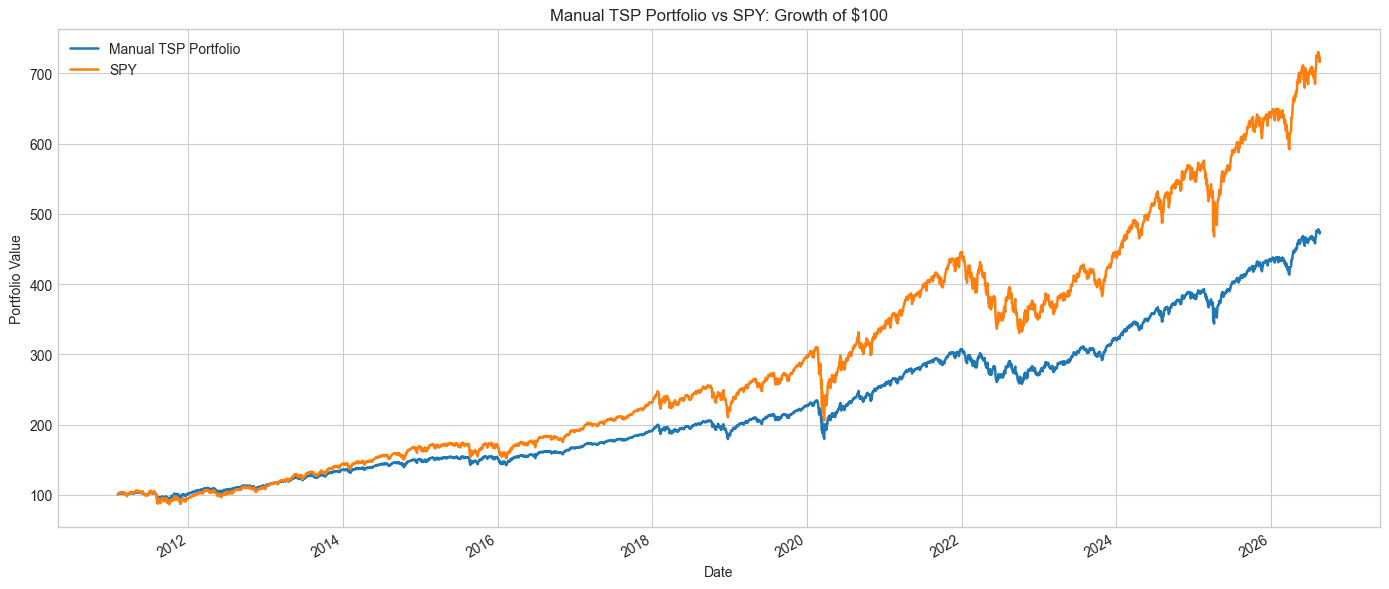

In [11]:
ax = comparison_value.plot(
    figsize=(14, 6),
    linewidth=1.8,
    title=f'Manual TSP Portfolio vs {BENCHMARK_TICKER}: Growth of $100',
)
ax.set_ylabel('Portfolio Value')
ax.set_xlabel('Date')
plt.tight_layout()
plt.show()